# Bank Customer Churn Prediction System

## Abstract

### **Introduction to the topic and motivation for the analysis**

Customer churn, is the phenomenon where customers terminate their relationship with a business or organization

 It is one of the most critical challenges facing the banking and financial services industry. "Churn prediction is used to identify customers who are about to leave a service provider. **It costs a
corporation 5 to 20 times more to keep a single customer than it does to acquire a new one**" (Sagala & Permai, 2021).

<br>

#### **Description of the purpose of the report**

This project aims to leverage **machine learning** and **statistical analysis** on a dataset of 10,000 bank customers. We want to **identify the key drivers of churn** and **build a predictive model capable of flagging at-risk customers** before they leave.

<br>

#### **Data used to perform the analysis**
Kaggle dataset :
https://www.kaggle.com/datasets/shantanudhakadd/bank-customer-churn-prediction

* By **analyzing demographic factors** such as **age**, **geography**, and **gender** alongside behavioral and **financial indicators** like **account balance**, **number of products held**, and **activity status**, we seek to uncover actionable patterns that can inform targeted retention strategies.
* The insights derived from this analysis could enable the bank to proactively engage vulnerable customer segments, optimize resource allocation for retention campaigns, and ultimately reduce revenue loss.

#### **Problematique:** How can we accurately identify customers at risk of churning?

#### **Proposed Methodology**
1. Project Setup
2. EDA
3. Feature Engineering
4. Statistical Analysis
5. Modeling Comparison

#### **Statisticall Analysis**
After this analysis, our results are as follows:
* The dataset showed no critical missingness affecting the main variables used for analysis.
* We tested 3 features : age, customer activity and balance
* Statistical testing confirmed several significant differences between churned and non-churned customers:
    * Age: We are 95% confident that churned customers are between 8.52 and 9.48 years older, on average, than non-churned customers (observed ≈ 9.00 years, t = 30.42, p < 0.001).
    * Customer Activity: The association between activity status and churn was statistically significant (χ² = 242.99, p < 0.001). Inactive customers showed a substantially higher churn rate (26.9%) compared to active customers (14.3%), indicating that customer engagement is strongly linked to retention.
    * Balance: A Mann–Whitney test indicated that the distribution of account balances differs significantly between churned and non-churned customers (p < 0.001). Churned customers had a higher median balance (≈ 109,349) compared to non-churned customers (≈ 92,073), suggesting that higher-balance clients are more likely to leave.


#### **Model Analyses**
Model evaluation revealed a trade-off between predictive performance metrics.
* Logistic Regression achieved the highest recall (~78%), making it the most effective model for identifying churners, but at the cost of lower precision (~46%).
* Random Forest achieved higher overall accuracy (~85%) and precision (~70%), but with lower recall (~50%), indicating that it misses a larger proportion of churners.
* Further more a comparison between baseline and statistically refined models showed that removing non-significant features had minimal impact on performance,

## 1.Project Setup

In [245]:
# Imports
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning (scikit-learn)
import sklearn
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, recall_score, precision_score,
                             f1_score, confusion_matrix, roc_auc_score, roc_curve)



# Statistical Tests
# - let's see if we can get a better model by doing static analysis yay
from scipy.stats import ttest_ind, chi2_contingency, mannwhitneyu,t

In [246]:
# Data import
df = pd.read_csv("Churn_Modelling.csv")
df_stat_analisys = df.copy()

In [247]:
print("=" * 67)
print("THE FIRST 5 CUSTOMERS ")
print("=" * 67)
print(df.head())
print("\n")

print("=" * 67)
print("THE STATISTICAL METRICS FOR EACH ROW ")
print("=" * 67)

print(df.describe())
print("\n")

print("=" * 67)
print("ROW X COLS")
print("=" * 67)
print(df.shape)



# From here we can already decice what features we'll exclude
# starting with row number, customerID and surnames
# also exited will be our target
# features are to be determind

THE FIRST 5 CUSTOMERS 
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63 

### Data Dictionary

Data dictionary is in the kaggle dataset, but we'll copy and paste the info for clarity sake.
* RowNumber : Row Number Of dataset
* CustomerId : CustomerID is given
* Surname : Surname of the customer
* CreditScore : Credit Score of customer
* Geography : location of customer
* Gender : Gender whether male or female
* Age : Age of the customer
* Tenure : From how many years customer is in bank
* Balance : Average balance of customer
* NumOfProducts : Number of bank product facilities customer is using
* HasCrCard : do they have a credit card
* IsActiveMember : A customer who has been recently and regularly engaging with the bank (not made clear in the data set- we will work on this assumption)
* EstimatedSalary : estimated salary
* Exited : left the bank or not

Now we will search if we have any null entries

In [248]:
# We clearly see all the collumn names and that there are no missing entries
print("=" * 67)
print("COLUMN NAMES")
print("=" * 67)

print(df.info())
print("\n")

print("=" * 67)
print("ANY MISSING ENTRIES?")
print("=" * 67)

print(df.isnull().sum())

COLUMN NAMES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


ANY MISSING ENTRIES?
RowNumber          0
CustomerId         0
Surname    

## 2. EDA

In [249]:
# suspected categorical data
print(df['Gender'].unique())
print(df['Geography'].unique())


['Female' 'Male']
['France' 'Spain' 'Germany']


#### Basic Data Vizualization
* We'll use bar charts for our boolean values : gender, geographie, has credit card, is active member and exited
* We'll use box plots for our numerical values : credi score, age, tenure, balance, nums of products and estimated salary

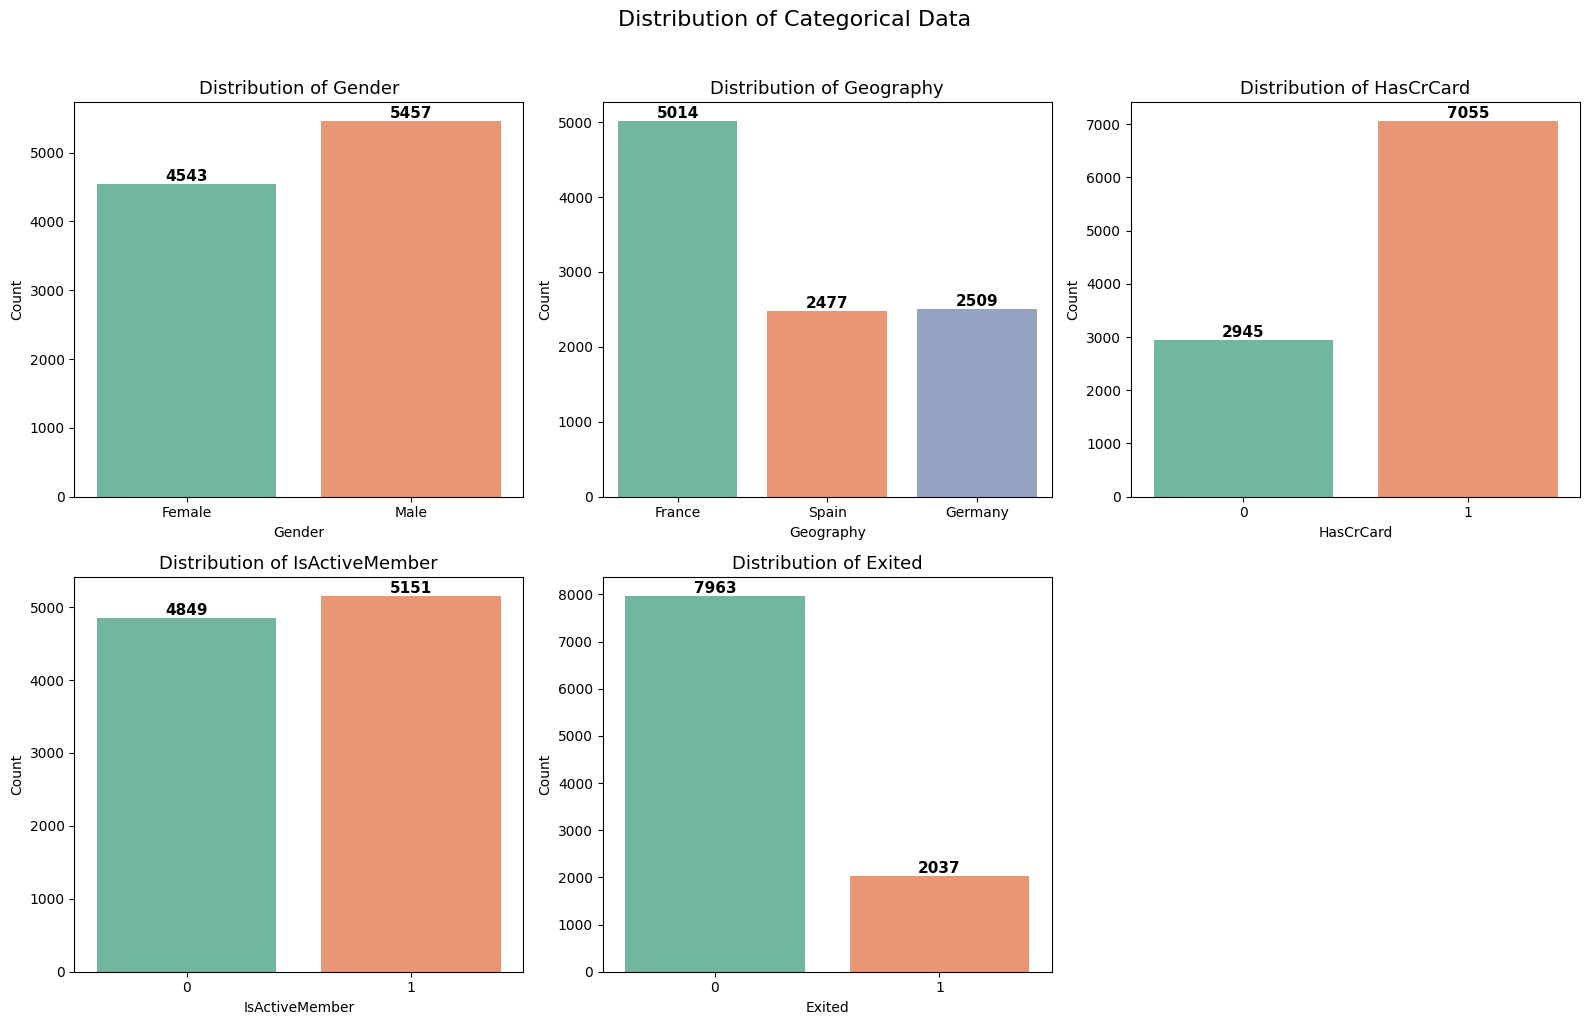

In [250]:
# Categorical data and  Bar Charts

categorical_var = ['Gender', 'Geography', 'HasCrCard', 'IsActiveMember', 'Exited']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(categorical_var):
    ax = axes[i]
    sns.countplot(data=df, x=var, hue=var, legend=False, ax=ax, palette='Set2')

    ax.set_title(f'Distribution of {var}', fontsize=13)
    ax.set_xlabel(var)
    ax.set_ylabel('Count')

    # Coutn labels
    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_height())}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )
axes[5].set_visible(False)

plt.suptitle('Distribution of Categorical Data', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Observations
* there are significantly a lot more clients who have not exited the bank, who have a credit card
* we have a relatively similar distribution of active memeber, both genders
* we seem to have a lot more membes from france , compared to spain and germany

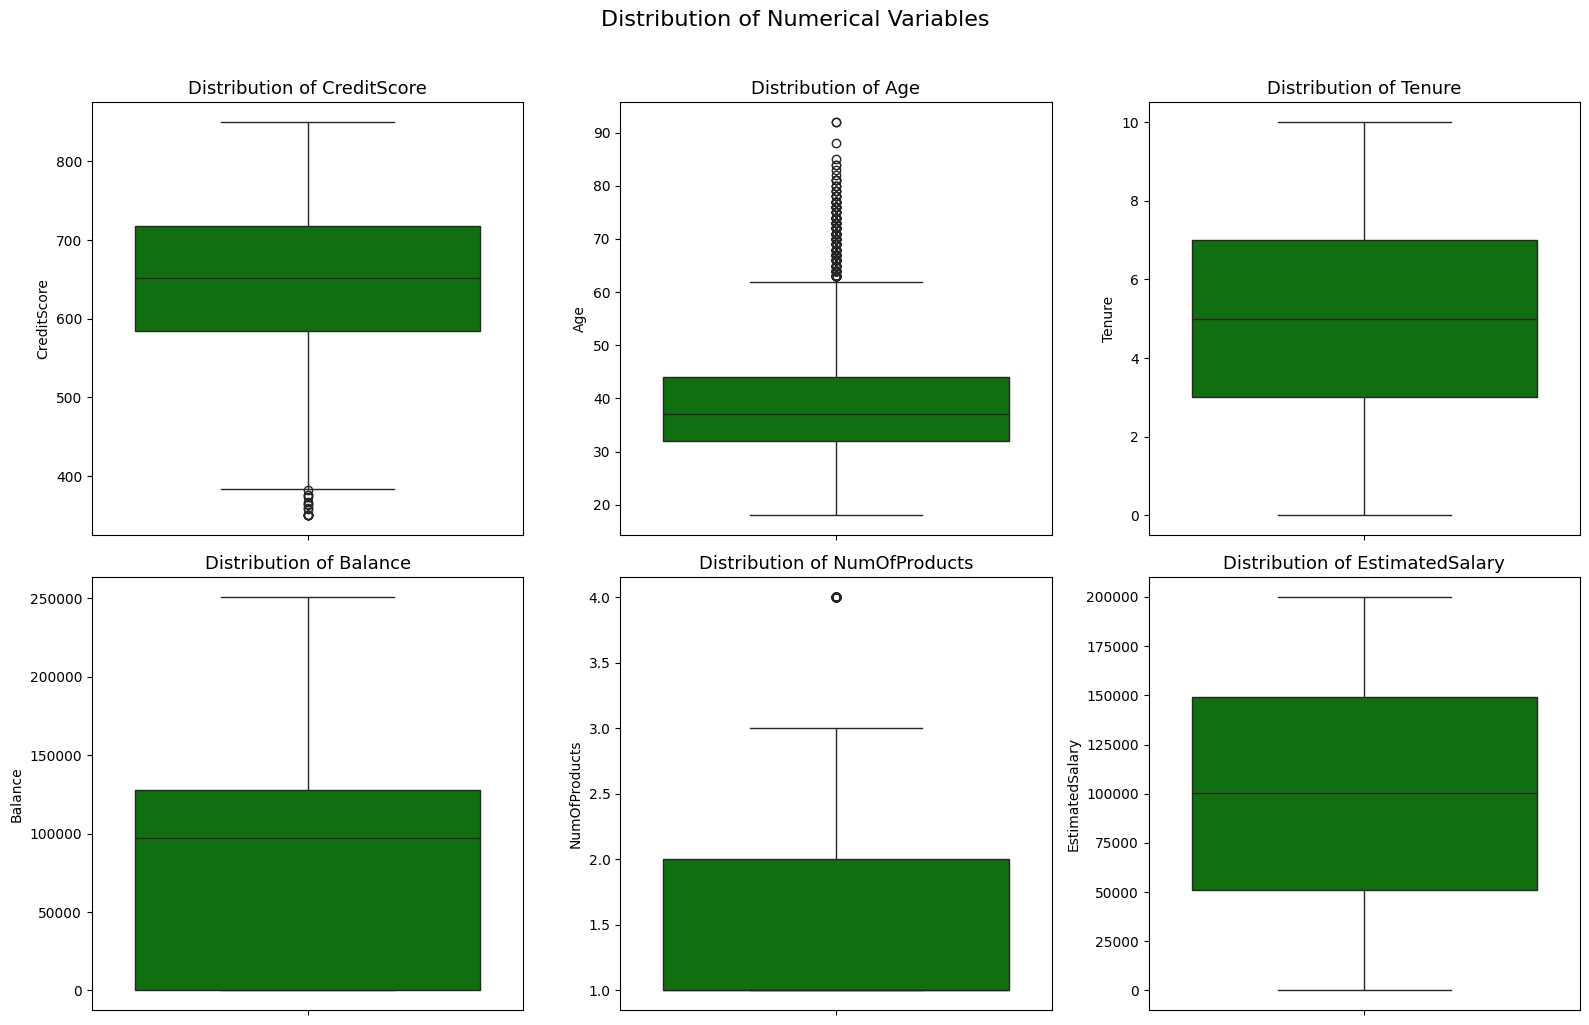

In [251]:
# Numerical data and box plots

num_var = ['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(num_var):
    sns.boxplot(data=df, y=var,ax=axes[i],color='green')

    axes[i].set_title(f'Distribution of {var}', fontsize=13)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(var)

plt.suptitle('Distribution of Numerical Variables', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

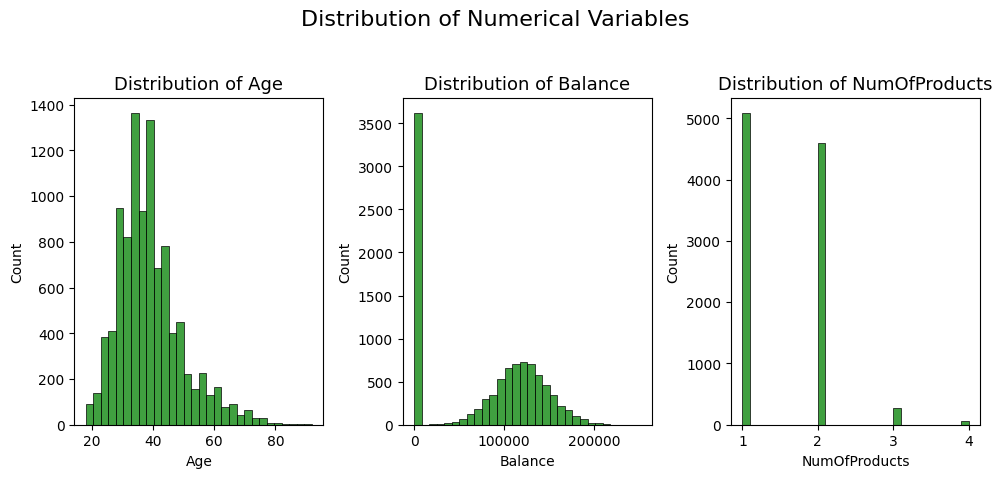

In [252]:
# Histograms for numeric data
num_var = ['Age','Balance','NumOfProducts']

fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()

for i, var in enumerate(num_var):
    sns.histplot(data=df, x=var, bins=30, kde=False, ax=axes[i], color='green')

    axes[i].set_title(f'Distribution of {var}', fontsize=13)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Count')

# Remove empty subplots (since you only have 3 variables)
for j in range(len(num_var), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution of Numerical Variables', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Observations
* we see normal distributions in the cred scores,tenure and estimated salary
* for the age ditribution we can see it be bimodal and right skewed, thesefore, we'll use the median over the mean, sice it will have more statistical relevance
* distribution of balance, we can observe it be bimodal aswell, with a lot of the  clients having 0 for balance and the next being normaly distributed
* Ditribution of num of products, looks like a categorical data, should be turned categorical.


##### We want to see the relationship between Churn and other features

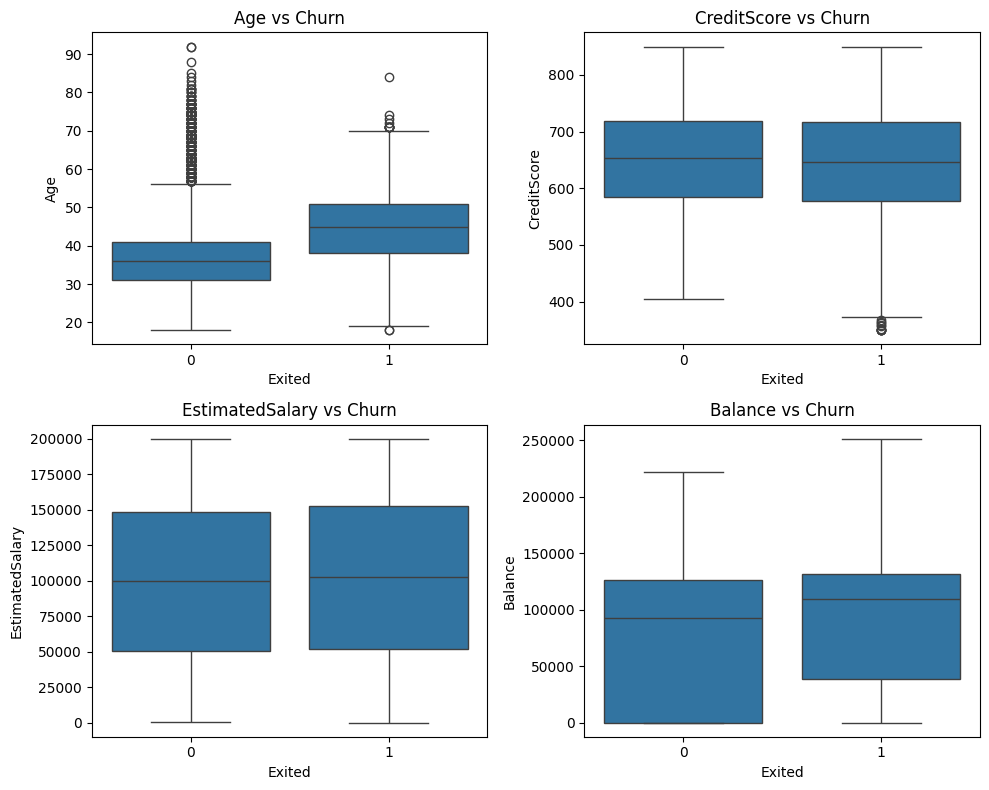

In [253]:
# Churn vs ...
vars_to_plot = ['Age', 'CreditScore', 'EstimatedSalary', 'Balance']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    sns.boxplot(data=df, x='Exited', y=var, ax=axes[i])
    axes[i].set_title(f'{var} vs Churn')

plt.tight_layout()
plt.show()

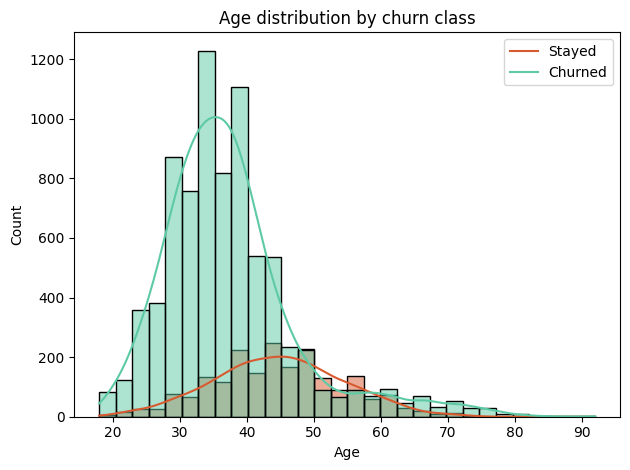

In [254]:
# Churn vs Age

sns.histplot(data=df, x='Age', hue='Exited', bins=30,
             kde=True, palette={0: '#5DCAA5', 1: '#D85A30'})

plt.title('Age distribution by churn class')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

Observations
* Customers who stay tend to be older on average, with a noticeable shift toward the 40–55 age range. With a lot of clients who Churn around their mid 30s

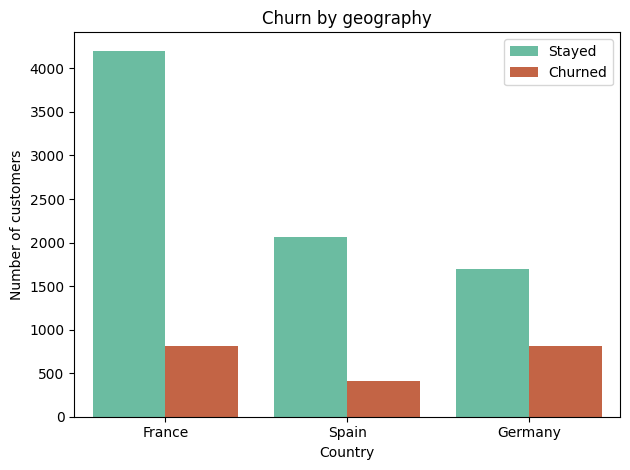

In [255]:
# Churn vs Geographie

sns.countplot(data=df, x='Geography', hue='Exited',
              palette={0: '#5DCAA5', 1: '#D85A30'})

plt.title('Churn by geography')
plt.xlabel('Country')
plt.ylabel('Number of customers')
plt.legend(labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

Observations
* Most clients seem to stay from all 3 countries
* Germany has a lot more clients who churn compared to the rest (ratio wise)

/tmp/ipykernel_15002/3503730526.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Inactive', 'Active'])


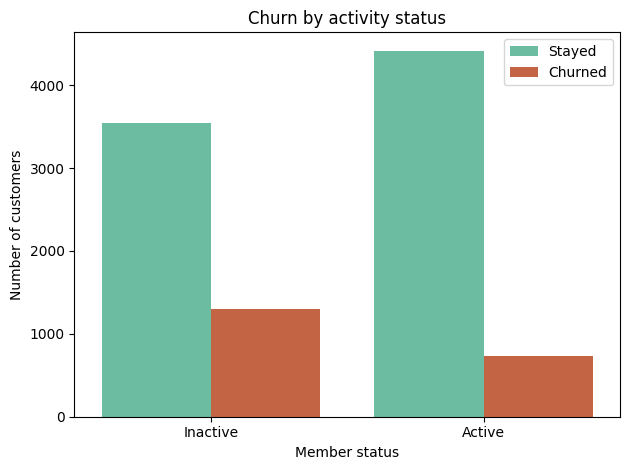

In [256]:
# Churn vs Active member

ax = sns.countplot(data=df, x='IsActiveMember', hue='Exited',
                   palette={0: '#5DCAA5', 1: '#D85A30'})

ax.set_xticklabels(['Inactive', 'Active'])
ax.set_title('Churn by activity status')
ax.set_xlabel('Member status')
ax.set_ylabel('Number of customers')
plt.legend(labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

Observations
* Inactive memebrs also seem to be more likely to churn ratio wise compared to those who are active

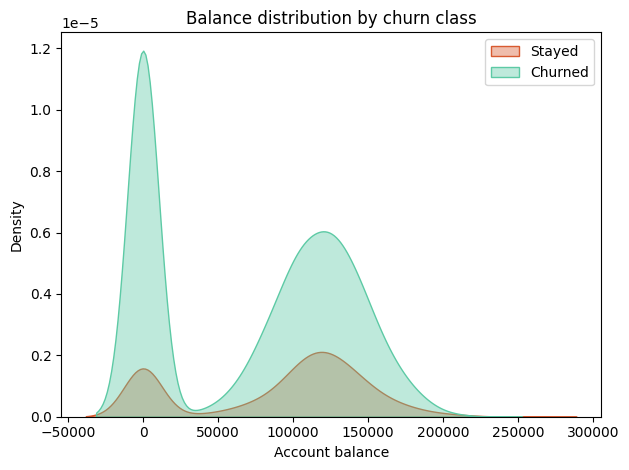

In [257]:
# Churn Vs balance

sns.kdeplot(data=df, x='Balance', hue='Exited',
            fill=True, alpha=0.4, palette={0: '#5DCAA5', 1: '#D85A30'})

plt.title('Balance distribution by churn class')
plt.xlabel('Account balance')
plt.ylabel('Density')
plt.legend(labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

Observations
* We still observe the distribution to eb bimodal on both churn and stayed
* what we can observe, which wasn't obvious on the other graphs is that lower balance and finacial stabilty have both an impact in staying and churning
  * the highest peak in the Churned graph is primarely when the balance is low
  * the highest peak in the Stayed graph is primarely when the balance is higher (around 125.000)

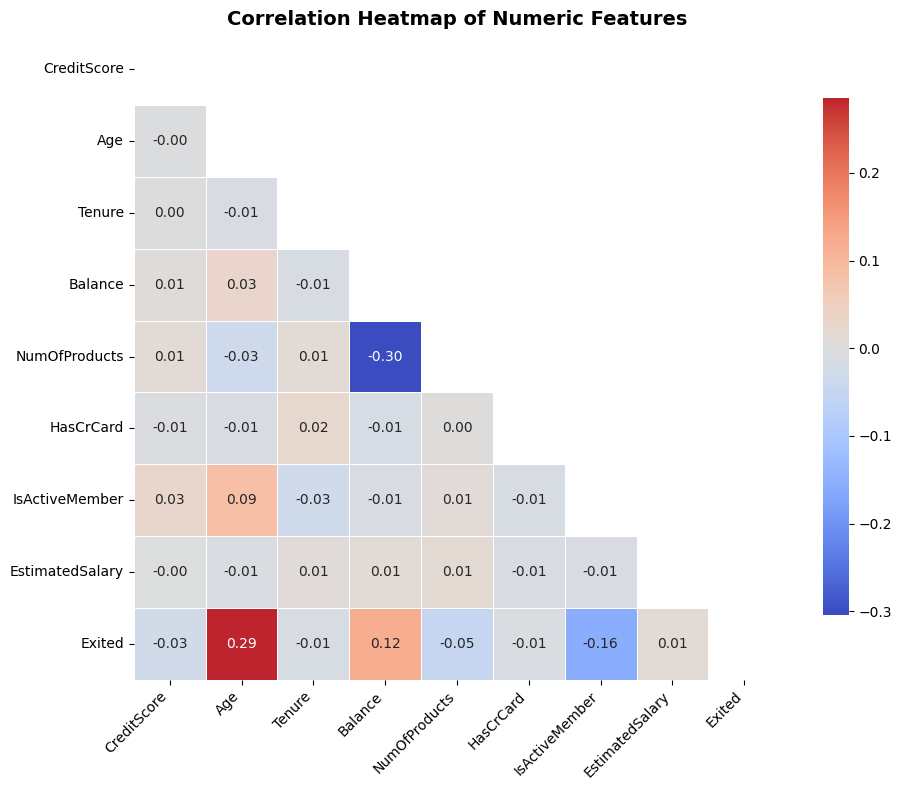

In [258]:
# Correlation Heat map

df_numeric = df.select_dtypes(include=[np.number]).copy()

# Drop only columns that exist in the numeric dataframe

df_numeric = df_numeric.drop(columns=["RowNumber", "CustomerId"], errors="ignore")

corr_matrix = df_numeric.corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(10, 8))

# Plot heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap of Numeric Features", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Observations
* variables seem to be independent, so we don't much multicolinearity
* we observe a strong relationship between churn and age, moderate corelation between, churn and balance, and negative ocrelation beween  activity and churning (this shows that active memebers are less likely to churn)
* There's also strong negative corelation between balance and number of products, which can be interpreted as lower balance could imply a high number of products

###### Data Vizualization Conclusions Summary

* Most variables show weak correlations with each other, indicating:
    * Low multicollinearity
    * Each feature provides distinct information
* Age is the strongest driver of churn:
    * Higher churn observed in the 40–55 age range
* Balance has a moderate positive relationship with churn:
    * Customers with higher balances are more likely to churn
* Customer activity is negatively correlated with churn:
    * Active members are significantly less likely to leave
* Geography shows clear differences:
    * Germany has a higher churn rate than France and Spain
    * Most customers stay across all countries, but churn is proportionally higher in Germany
* Balance and NumOfProducts are negatively correlated:
    * Customers with more products tend to have lower balances
    * Suggests distinct customer profiles

Distribution Insights
* HasCrCard, Tenure, and EstimatedSalary:
    * Show little difference between churned and non-churned customers
    * Limited predictive power
    * we'll remove these in model B
* Age and Balance:
    * Show skewness and bimodality
    * Stronger relevance for modeling
* Balance distribution is bimodal:
    * Large group with zero balance
    * Another group with higher balances
* NumOfProducts is discrete:
    * Behaves like a categorical variable
    * Should be categorical in modeling

###### Statistical Analysis Prelude

From all we've seen so far, we can now determin what statitical test are most interesting to perform on our data.
* we will perform a t-test for Chrun vs Age
  * we will check the mean of age churn groups, to see if churnurs are significantly orlder than non churnurs
* we will perform a chi-squared for Chrun vs active memebrs.
  * checks if churn is dependent on activity
* we will perform a Mann-Whitney for Chrun vs Balance.
  * Check if churners and non-churners have different balance patterns


## 3. Feature Engineering

In [259]:
# dropping some of the afordmentioned not very useful columns
df.drop(["RowNumber", "CustomerId", "Surname"], axis=1, inplace=True)
print(df.shape)

(10000, 11)


In [260]:
# one hot encoding Countries
# one hot encoding number of products and turning it into 3 categories
# Label encoding Gender

encoder = OneHotEncoder(drop='first', sparse_output=False)

# Geographie
geo_encoded = encoder.fit_transform(df[['Geography']])

geo_df = pd.DataFrame(geo_encoded, columns=encoder.get_feature_names_out(['Geography']))
df = pd.concat([df.drop(columns=['Geography']), geo_df], axis=1)

# Num of products
# Grouping 3 and 4 become  to become 3+
df['NumOfProductsGroup'] = df['NumOfProducts'].replace({  1: '1', 2: '2', 3: '3+', 4: '3+'})
products_encoded = encoder.fit_transform(df[['NumOfProductsGroup']])

products_df = pd.DataFrame(products_encoded, columns=encoder.get_feature_names_out(['NumOfProductsGroup']), index=df.index)
df = pd.concat( [df.drop(columns=['NumOfProducts', 'NumOfProductsGroup']), products_df], axis=1)


# Gender
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# print the new data frame
df.head()

,CreditScore,Gender,Age,Tenure,Balance,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,NumOfProductsGroup_2,NumOfProductsGroup_3+
0,619,0,42,2,0.00,1,1,101348.88,1,0.0,0.0,0.0,0.0
1,608,0,41,1,83807.86,0,1,112542.58,0,0.0,1.0,0.0,0.0
2,502,0,42,8,159660.80,1,0,113931.57,1,0.0,0.0,0.0,1.0
3,699,0,39,1,0.00,0,0,93826.63,0,0.0,0.0,1.0,0.0
4,850,0,43,2,125510.82,1,1,79084.10,0,0.0,1.0,0.0,0.0


#### Preping for the our Modeling
 Our models will basically calisfy the customers into those who stay and does who churn. We first used statistical tests to identify relevant features. We then compared models trained with all features versus statistically selected features to evaluate the impact on predictive performance. We will use 4 models:
 * Model A : All features
   * Logistic regression
   * Random Forest
 * Model B : Statistically tested
   * Logistic regression
   * Random Forest

=> A/B comparison test

To Achive this we will first have to Start with doing
* choose our target and features
* do a training split 80/20
* Scale our data since we will perform an Logistc Regression


In [261]:
# Choose target and features

# Choosing Traget
y = df['Exited']

# Choosing for Baseline Model A : Features for All feature Models
X_all = df.drop(columns=['Exited'])

# Model B: statistically guided model
X_selected =  df.drop(columns=['Exited','HasCrCard', 'Tenure', 'EstimatedSalary'])


# training Split 80/20 : 80% of the dat will be used to train the model, 20% will be used to test the models
#for model A
X_all_train, X_all_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, stratify=y, random_state=67 )


# for model B
X_selected_train = X_selected.loc[X_all_train.index]
X_selected_test = X_selected.loc[X_all_test.index]

# Split Check
print("Model A - X_train:", X_all_train.shape)
print("Model A - X_test: ", X_all_test.shape)

print("\nModel B - X_train:", X_selected_train.shape)
print("Model B - X_test: ", X_selected_test.shape)

print("\nClass balance in test set:")
print(y_test.value_counts(normalize=True).round(3))

Model A - X_train: (8000, 12)
Model A - X_test:  (2000, 12)

Model B - X_train: (8000, 9)
Model B - X_test:  (2000, 9)

Class balance in test set:
Exited
0    0.796
1    0.204
Name: proportion, dtype: float64


In [262]:
# Scaled data for Logistic regression

scale_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

# Scaling model A
X_all_train = X_all_train.copy()
X_all_test = X_all_test.copy()

X_all_train[scale_cols] = X_all_train[scale_cols].astype(float)
X_all_test[scale_cols] = X_all_test[scale_cols].astype(float)

scaler_all = StandardScaler()

X_all_train.loc[:, scale_cols] = scaler_all.fit_transform(X_all_train[scale_cols])
X_all_test.loc[:, scale_cols] = scaler_all.transform(X_all_test[scale_cols])


scale_cols_selected = ['Age', 'Balance', 'CreditScore']
# Scaling model B
X_selected_train = X_selected_train.copy()
X_selected_test = X_selected_test.copy()

X_selected_train[scale_cols_selected] = X_selected_train[scale_cols_selected].astype(float)
X_selected_test[scale_cols_selected] = X_selected_test[scale_cols_selected].astype(float)

scaler_selected = StandardScaler()

X_selected_train.loc[:, scale_cols_selected] = scaler_selected.fit_transform(X_selected_train[scale_cols_selected])
X_selected_test.loc[:, scale_cols_selected] = scaler_selected.transform(X_selected_test[scale_cols_selected])


## 4. Statistical Analysis

### 1. t-test - age vs churn
* age skewed to the right so we'll use the median, for accuracy sake
* Question : Are churners older than non-churners?
* H0 : The median age of churned and non-churned customers is the don't impact churn rate.
* H1 : The median age of churned customers is higher than that of non-churned customers.
* The t-statistic measures how far apart two group median are, relative to the variability in the data.
* if the T-statistic is large, it is key evidence in rejecting H0


Statistical Analysis:
* The comparison of age between churned and non-churned customers yielded a statistically significant difference.

* Age (Churn vs Non-Churn):We are 95% confident that the true difference in median age between churned customers and non-churned customers lies between 8.52 and 9.48 years. (observed ≈ 9.00 years, t = 30.42, p < 0.001). This indicates that customers who churn are significantly older than those who remain.

Interpretation:
* we reject H0
* Age shows a strong and statistically significant association with churn.
* The confidence interval is narrow, indicating a precise estimate of the effect.
* The positive interval confirms that the effect is consistently in one direction (churners are older).

In [263]:
# our roups
age_churn = df[df['Exited'] == 1]['Age']
age_stay  = df[df['Exited'] == 0]['Age']

# t-test
t_stat, p_val = ttest_ind(age_churn, age_stay, equal_var=False)

# median differnece
med_diff = age_churn.median() - age_stay.median()

# Standard error
se = np.sqrt( age_churn.var(ddof=1)/len(age_churn) + age_stay.var(ddof=1)/len(age_stay))

# degrees of freedom
dfree = (
    (age_churn.var(ddof=1)/len(age_churn) + age_stay.var(ddof=1)/len(age_stay))**2
    /
    ((age_churn.var(ddof=1)/len(age_churn))**2/(len(age_churn)-1) +
     (age_stay.var(ddof=1)/len(age_stay))**2/(len(age_stay)-1))
)

# confidence interval
t_crit = t.ppf(0.975, dfree)

ci_low = med_diff - t_crit * se
ci_high = med_diff + t_crit * se


# results
print("="*67)
print("T-TEST + CONFIDENCE INTERVAL — AGE vs CHURN")
print("="*67)

print(f"Median Age (Churned):     {age_churn.median():.4f}")
print(f"Median Age (Non-Churned): {age_stay.median():.4f}")
print(f"Median Difference:        {med_diff:.4f}")

print(f"\nT-statistic: {t_stat:.6f}")
print(f"P-value:     {p_val:.8f}")

print(f"\n95% Confidence Interval: [{ci_low:.2f}, {ci_high:.2f}]")

# Interpretation
if p_val < 0.05:
    print("\nSignificant difference.")
    if ci_low > 0:
        print("Churners are significantly older.")
    elif ci_high < 0:
        print("Churners are significantly younger.")
else:
    print("\nNo significant difference.")

T-TEST + CONFIDENCE INTERVAL — AGE vs CHURN
Median Age (Churned):     45.0000
Median Age (Non-Churned): 36.0000
Median Difference:        9.0000

T-statistic: 30.419197
P-value:     0.00000000

95% Confidence Interval: [8.52, 9.48]

Significant difference.
Churners are significantly older.


### 2. Chi-Squared test Churn vs is a memmber active
* question : Does a memeber being active affect churn?
* H0: Customer activity and churn have no relationship.
* H1: Customer activity and churn are dependent.

Statistical Analysis:
*  Activity Status (Active vs Inactive):
* The distribution of churn differs significantly between active and inactive customers (χ² = 242.99, p < 0.001).
* Inactive customers exhibit a substantially higher proportion of churn (1302 / 4849 ≈ 26.9%) compared to active customers (735 / 5151 ≈ 14.3%).

Interpretation:
* we reject H0
* Customer activity is strongly associated with churn.
* Inactive customers have a substantially higher churn rate (26.9%) compared to active customers (14.3%), indicating that lack of activity is strongly associated with increased likelihood of churn.


In [264]:
ct_activity = pd.crosstab(df['IsActiveMember'], df['Exited'])


chi2, p_val, _, _ = chi2_contingency(ct_activity)

print("\n2. CHI-SQUARE — Activity vs Churn")
print("-"*67)
print(ct_activity)
print("\n")
print(f"Chi2: {chi2:.4f}")
print(f"P-value: {p_val:.6f}")

if p_val < 0.05:
    print("Significant: churn depends on activity.")
else:
    print("No significant relationship.")


2. CHI-SQUARE — Activity vs Churn
-------------------------------------------------------------------
Exited             0     1
IsActiveMember            
0               3547  1302
1               4416   735


Chi2: 242.9853
P-value: 0.000000
Significant: churn depends on activity.


### 3. Mann-Whitney Churn vs balance
* question : Do churned and non-churned customers have different balance distributions?
* H0: The distribution of account balances is the same for churned and non-churned customers.
* H1: The distribution of account balances differs between churned and non-churned customers.

Statistical Analysis:
* Account balances differ significantly between churned and non-churned customers with a median of 109,349 vs 92,073, this shows a 17k difference in revenue from those who left and who staied
* There is a substantially greater than 50% chance that the churned customer will have a higher balance.
  * There's a 57.77% chance that a churned customer has a higher balance than a non-churned customer
  * Under the null hypothesis, there is a 50% chance that a churned customer has a higher balance than a non-churned customer. Since the test is highly significant, this probability is meaningfully different from 50%, indicating a systematic difference between the groups.

Interpretation:
* Customers who churn tend to have higher account balances than those who remain.
* The difference is statistically significant, meaning it is unlikely to be due to random variation.
* This suggests that customers with higher balances are more likely to churn, highlighting a potentially valuable segment at risk.



In [265]:
# Groups
bal_churn = df[df['Exited'] == 1]['Balance']
bal_stay  = df[df['Exited'] == 0]['Balance']

# Mann whitney test
u_stat, p_val = mannwhitneyu(bal_churn, bal_stay)

#percentage
n1 = len(df[df['Exited']==1])
n2 = len(df[df['Exited']==0])

P = (u_stat / (n1 * n2))*100


print("\n3. MANN-WHITNEY — Balance vs Churn")
print("-"*40)
print(f"Median Balance (Churned):     {bal_churn.median():.2f}")
print(f"Median Balance (Non-Churned): {bal_stay.median():.2f}")

print("\n")
print(f"U-statistic: {u_stat:.4f}")
print(f"P-value:     {p_val:.6f}")

print("\n")
print(f"There's a {P:.2f}% chance that a churned customer has a higher balance than a non-churned customer")

print("\n")
if p_val < 0.05:
    print("Significant difference: balance distributions differ.")
else:
    print("No significant difference.")


3. MANN-WHITNEY — Balance vs Churn
----------------------------------------
Median Balance (Churned):     109349.29
Median Balance (Non-Churned): 92072.68


U-statistic: 9371186.5000
P-value:     0.000000


There's a 57.77% chance that a churned customer has a higher balance than a non-churned customer


Significant difference: balance distributions differ.


## 5. Modeling

In [266]:
# Defining the 4 models
models = {
    "Model A - Logistic Regression" : LogisticRegression( class_weight='balanced', max_iter=1000, random_state=67),
    "Model A - Random Forest": RandomForestClassifier( n_estimators=200, max_depth=15, class_weight='balanced', random_state=67),

    "Model B - Logistic Regression" : LogisticRegression( class_weight='balanced', max_iter=1000, random_state=67),
    "Model B - Random Forest": RandomForestClassifier( n_estimators=200, max_depth=15, class_weight='balanced', random_state=67)
}


In [267]:
results = []

# Training and evaluation function for our models

def train_and_evaluate(name, model, X_train, X_test, y_train, y_test):

    # model
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    # metrics
    acc = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)

    # display
    print("=" * 67)
    print(name.upper())
    print("=" * 67)

    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")

    print("\n")

    print(classification_report(y_test, preds, target_names=['Stayed', 'Churned']))

    # Confusion matrix heatmap
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5, 4))

    sns.heatmap( cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Stayed', 'Predicted Churned'],
                 yticklabels=['Actual Stayed', 'Actual Churned'])

    plt.title(f"{name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": auc})

    return model, preds, proba

MODEL A - LOGISTIC REGRESSION
Accuracy  : 0.7665
Precision : 0.4568
Recall    : 0.7789
F1-score  : 0.5758
ROC-AUC   : 0.8353


              precision    recall  f1-score   support

      Stayed       0.93      0.76      0.84      1593
     Churned       0.46      0.78      0.58       407

    accuracy                           0.77      2000
   macro avg       0.69      0.77      0.71      2000
weighted avg       0.83      0.77      0.79      2000



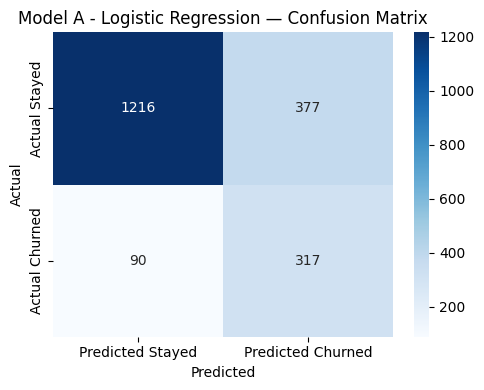

MODEL A - RANDOM FOREST
Accuracy  : 0.8550
Precision : 0.7038
Recall    : 0.4963
F1-score  : 0.5821
ROC-AUC   : 0.8548


              precision    recall  f1-score   support

      Stayed       0.88      0.95      0.91      1593
     Churned       0.70      0.50      0.58       407

    accuracy                           0.85      2000
   macro avg       0.79      0.72      0.75      2000
weighted avg       0.84      0.85      0.85      2000



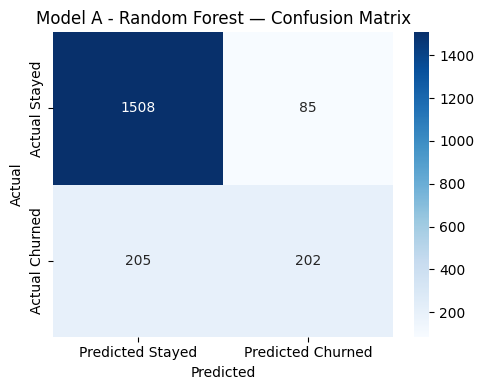

MODEL B - LOGISTIC REGRESSION
Accuracy  : 0.7665
Precision : 0.4566
Recall    : 0.7764
F1-score  : 0.5751
ROC-AUC   : 0.8363


              precision    recall  f1-score   support

      Stayed       0.93      0.76      0.84      1593
     Churned       0.46      0.78      0.58       407

    accuracy                           0.77      2000
   macro avg       0.69      0.77      0.71      2000
weighted avg       0.83      0.77      0.79      2000



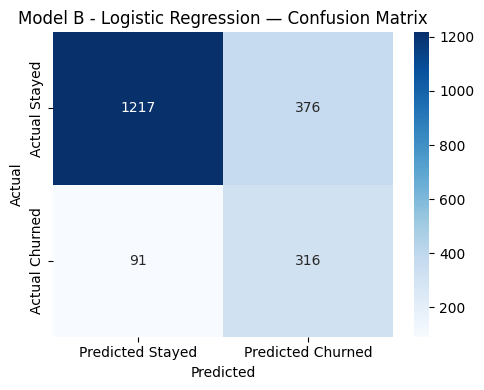

MODEL B - RANDOM FOREST
Accuracy  : 0.8480
Precision : 0.6656
Recall    : 0.5086
F1-score  : 0.5766
ROC-AUC   : 0.8478


              precision    recall  f1-score   support

      Stayed       0.88      0.93      0.91      1593
     Churned       0.67      0.51      0.58       407

    accuracy                           0.85      2000
   macro avg       0.77      0.72      0.74      2000
weighted avg       0.84      0.85      0.84      2000



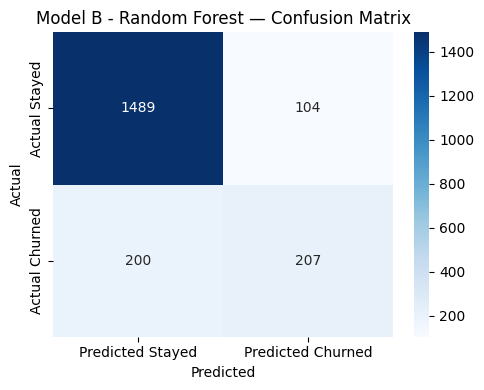

In [268]:
# runing the models


# Model A
model_a_log, preds_a_log, proba_a_log = train_and_evaluate(
    "Model A - Logistic Regression",
    models["Model A - Logistic Regression"],
    X_all_train, X_all_test, y_train, y_test)
model_a_rf, preds_a_rf, proba_a_rf = train_and_evaluate(
    "Model A - Random Forest",
    models["Model A - Random Forest"],
    X_all_train, X_all_test, y_train, y_test)


# Model B
model_b_log, preds_b_log, proba_b_log = train_and_evaluate(
    "Model B - Logistic Regression",
    models["Model B - Logistic Regression"],
    X_selected_train, X_selected_test, y_train, y_test )

model_b_rf, preds_b_rf, proba_b_rf = train_and_evaluate(
    "Model B - Random Forest",
    models["Model B - Random Forest"],
    X_selected_train, X_selected_test, y_train, y_test )

In [269]:
# Seeing the results

results_df = pd.DataFrame(results)

print("=" * 67)
print("Model Comparasion")
print("=" * 67)

display(results_df.round(4))

Model Comparasion


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Model A - Logistic Regression,0.7665,0.4568,0.7789,0.5758,0.8353
1,Model A - Random Forest,0.8550,0.7038,0.4963,0.5821,0.8548
2,Model B - Logistic Regression,0.7665,0.4566,0.7764,0.5751,0.8363
3,Model B - Random Forest,0.8480,0.6656,0.5086,0.5766,0.8478


Observations:<br>
LR vs RF :
* Logistic Regression achieves the highest recall (~78%) on both models, making it the best model for identifying churners, but at the cost of lower precision (more false positives). - **better for detecting churners**
* Random Forest achieves the highest accuracy (around 85%) and precision (~70%) on both models, meaning its predictions are more reliable overall, but it misses more churners (lower recall). - **better for reducing false alarms**

Model A vs Model B :
* Model B performs nearly the same as Model A across all metrics, despite using fewer features.
* This shows that feature selection can simplify our model without degrading its performance.


Trade Off depends on the buissiness goal :
* If the goal is to catch as many churners as possible, Logistic Regression is preferred.
* If the goal is to make more precise predictions, Random Forest is a better choice.

Conclusion:
To conclusde the goal of this project is to identify how we can accurately identify customers at risk of churning. Following our foundings we can say that in our opinion Logistic regression is the better choice to use as a model. The bank's goal is to retain as many customers as possible, althou precision is important, in this case we prefer to traded off in the hope of keeping as many customers as possible.

